In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

#  Checked the dimensions of the data (rows, columns)

In [3]:
print(df.shape)

(7043, 21)


In [4]:
print(df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [5]:
#To check for missing values in each column of the dataset
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [6]:
#To get a summary of the numerical columns in the dataset
print(df.describe())

       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [7]:
#To check duplicate row in dataset
print(df.duplicated().sum())

0


In [8]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df['TotalCharges'].dtype)
print(df['TotalCharges'].isnull().sum())

float64
11


In [9]:
print(df[df['TotalCharges'].isnull()])

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
488   4472-LVYGI  Female              0     Yes        Yes       0   
753   3115-CZMZD    Male              0      No        Yes       0   
936   5709-LVOEQ  Female              0     Yes        Yes       0   
1082  4367-NUYAO    Male              0     Yes        Yes       0   
1340  1371-DWPAZ  Female              0     Yes        Yes       0   
3331  7644-OMVMY    Male              0     Yes        Yes       0   
3826  3213-VVOLG    Male              0     Yes        Yes       0   
4380  2520-SGTTA  Female              0     Yes        Yes       0   
5218  2923-ARZLG    Male              0     Yes        Yes       0   
6670  4075-WKNIU  Female              0     Yes        Yes       0   
6754  2775-SEFEE    Male              0      No        Yes       0   

     PhoneService     MultipleLines InternetService       OnlineSecurity  ...  \
488            No  No phone service             DSL                  Yes  ... 

In [10]:
# Since there are only 11 rows with missing values in the 'TotalCharges' column, we can drop these rows from the dataset.
df.dropna(inplace=True)
print(df.shape[0])

7032


In [11]:
# Number of unique customers    
print(df['customerID'].nunique())

7032


In [12]:
# To analyze the categorical columns in the dataset, we can use the value_counts() method to see the distribution of values in each categorical column.
#  We can also use the nunique() method to see the number of unique categories in each column.
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))
    print(f"Unique categories: {df[col].nunique(dropna=False)}")


customerID
customerID
7590-VHVEG    1
5575-GNVDE    1
3668-QPYBK    1
7795-CFOCW    1
9237-HQITU    1
             ..
6840-RESVB    1
2234-XADUH    1
4801-JZAZL    1
8361-LTMKD    1
3186-AJIEK    1
Name: count, Length: 7032, dtype: int64
Unique categories: 7032

gender
gender
Male      3549
Female    3483
Name: count, dtype: int64
Unique categories: 2

Partner
Partner
No     3639
Yes    3393
Name: count, dtype: int64
Unique categories: 2

Dependents
Dependents
No     4933
Yes    2099
Name: count, dtype: int64
Unique categories: 2

PhoneService
PhoneService
Yes    6352
No      680
Name: count, dtype: int64
Unique categories: 2

MultipleLines
MultipleLines
No                  3385
Yes                 2967
No phone service     680
Name: count, dtype: int64
Unique categories: 3

InternetService
InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64
Unique categories: 3

OnlineSecurity
OnlineSecurity
No                     3497
Yes            

# Define Customer Churn KPIs

In [13]:
#1.Total Customers
total_customers = df['customerID'].nunique()
print(f"Total Customers: {total_customers}")

Total Customers: 7032


In [14]:
#2.✔ Churned Customers(number of customers who are not using service of company)
churned_customers = df[df['Churn'] == 'Yes']['customerID'].nunique()
print(churned_customers)

1869


In [15]:
# 3. Churn Rate (Measures percentage of customers leaving.)
# A high churn rate indicates that a company is losing customers at a rapid pace, which can be a sign of dissatisfaction with the product or service, or strong competition in the market.
churn_rate = (churned_customers / total_customers) * 100
print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 26.58%


In [16]:
#4. Average Revenue Per User (ARPU)
average_revenue_per_user = df['MonthlyCharges'].mean()
print(f"Average Revenue Per User (ARPU): ${average_revenue_per_user:.2f}")

Average Revenue Per User (ARPU): $64.80


In [17]:
#5. Customer Lifetime Value (Basic)
Customer_Lifetime_values=df['TotalCharges'].mean()
print(Customer_Lifetime_values)


2283.300440841866


In [18]:
df.to_csv('CustomerChurnAnalysisCleaned.csv', index=False) 

# Visualize the relationship between Customer Churn and Contract Type using a bar chart

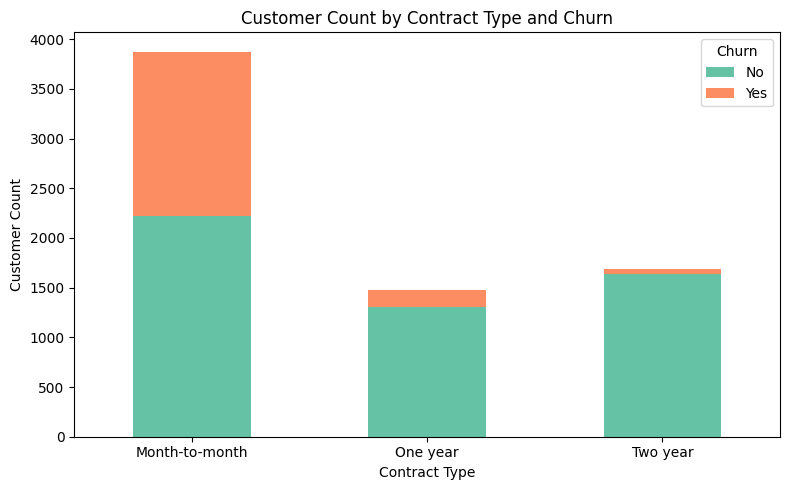

In [19]:
contract_churn = pd.crosstab(df['Contract'], df['Churn'])
colors = sns.color_palette("Set2", n_colors=contract_churn.shape[1])

ax = contract_churn.plot(
    kind='bar',
    stacked=True,
    color=colors,
    figsize=(8, 5)
)
ax.set_xlabel('Contract Type')
ax.set_ylabel('Customer Count')
ax.set_title('Customer Count by Contract Type and Churn')
ax.legend(title='Churn')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Machine Learning Models for prediction 
1.Logistic Regression

In [21]:
df.drop(columns=['customerID'], inplace=True)
print(df.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [22]:
df_encoded = pd.get_dummies(df, drop_first=True)
print(df_encoded.head())
print(df_encoded.shape)

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1           29.85         29.85        False   
1              0      34           56.95       1889.50         True   
2              0       2           53.85        108.15         True   
3              0      45           42.30       1840.75         True   
4              0       2           70.70        151.65        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  MultipleLines_Yes  ...  StreamingTV_Yes  \
0                            True              False  ...            False   
1                           False              False  ...            False   
2                         

In [25]:
print(df_encoded.columns)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Churn_Yes'],
      dtype='object')


In [26]:
print(df_encoded['Churn_Yes'].value_counts())

Churn_Yes
False    5163
True     1869
Name: count, dtype: int64


In [27]:
from sklearn.model_selection import train_test_split

# Split the encoded dataframe into features and target
X = df_encoded.drop('Churn_Yes', axis=1)
y = df_encoded['Churn_Yes']

# Split into training and test sets, stratifying by churn to keep class balance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [28]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5625, 30)
X_test shape: (1407, 30)
y_train shape: (5625,)
y_test shape: (1407,)


In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr_model = LogisticRegression(max_iter=1000, class_weight='balanced',random_state=42)
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

print(f"Logistic Regression test accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("Classification report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

Logistic Regression test accuracy: 0.7271
Classification report:
              precision    recall  f1-score   support

    No Churn       0.90      0.70      0.79      1033
       Churn       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407

Confusion matrix:
[[726 307]
 [ 77 297]]


c:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                                  feature  coefficient
25                      Contract_Two year    -1.469169
24                      Contract_One year    -0.789862
8          MultipleLines_No phone service     0.529322
13                     OnlineSecurity_Yes    -0.493009
19                        TechSupport_Yes    -0.450143
28         PaymentMethod_Electronic check     0.407855
10            InternetService_Fiber optic     0.391285
7                        PhoneService_Yes    -0.352465
26                   PaperlessBilling_Yes     0.263026
15                       OnlineBackup_Yes    -0.254981
6                          Dependents_Yes    -0.226313
0                           SeniorCitizen     0.201280
9                       MultipleLines_Yes     0.189692
21                        StreamingTV_Yes     0.092169
23                    StreamingMovies_Yes     0.077844
27  PaymentMethod_Credit card (automatic)     0.076542
17                   DeviceProtection_Yes    -0.072460
14       O

C:\Users\user\AppData\Local\Temp\ipykernel_1992\1931066786.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


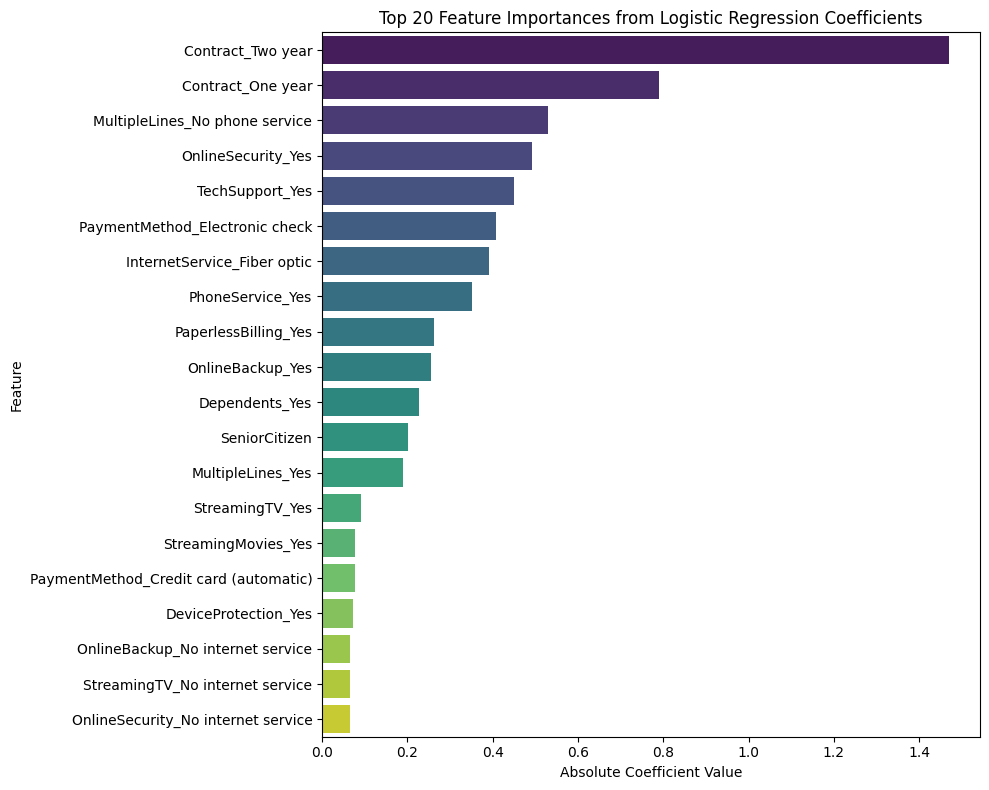

In [31]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lr_model.coef_[0]
})
importance_df['importance'] = importance_df['coefficient'].abs()
importance_df = importance_df.sort_values(by='importance', ascending=False)

print(importance_df[['feature', 'coefficient']].head(20))

plt.figure(figsize=(10, 8))
sns.barplot(
    data=importance_df.head(20),
    x='importance',
    y='feature',
    palette='viridis'
)
plt.title('Top 20 Feature Importances from Logistic Regression Coefficients')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Segmentation

In [32]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

seg_features = X.copy()

scaler = StandardScaler()
seg_scaled = scaler.fit_transform(seg_features)

inertia = []
K = range(2, 7)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(seg_scaled)  # fit the KMeans model on the scaled segmentation features
    inertia.append(km.inertia_)


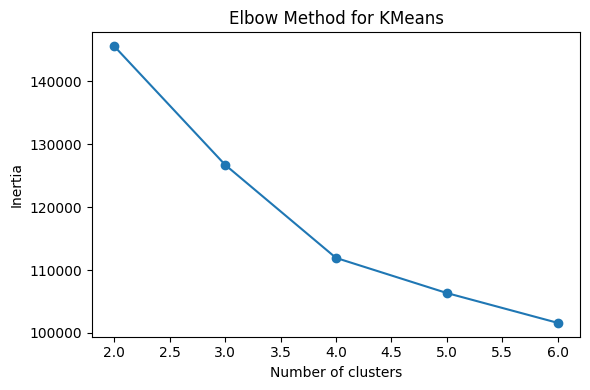

   Segment  customers  churn_rate  avg_tenure  avg_monthly    avg_total
0        0       1520    7.434211   30.667763    21.076283   665.220329
1        1        680   25.000000   31.830882    41.992500  1500.433750
2        2       2733   46.688621   15.538968    73.965368  1171.147384
3        3       2099   14.768938   55.865650    91.911768  5156.737994


In [33]:
# Plot the elbow curve to help choose the number of clusters
plt.figure(figsize=(6, 4))
plt.plot(K, inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for KMeans')
plt.tight_layout()
plt.show()

# Fit KMeans with the chosen number of clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(seg_scaled)
segment_labels = kmeans.labels_

# Create a segmentation dataframe by adding the cluster labels back to the original dataset
seg_df = df.copy()
seg_df['Segment'] = segment_labels

# Summarize each segment with key customer metrics
segment_summary = seg_df.groupby('Segment').agg(
    customers=('Churn', 'count'),
    churn_rate=('Churn', lambda s: (s == 'Yes').mean() * 100),
    avg_tenure=('tenure', 'mean'),
    avg_monthly=('MonthlyCharges', 'mean'),
    avg_total=('TotalCharges', 'mean')
).reset_index()

print(segment_summary)

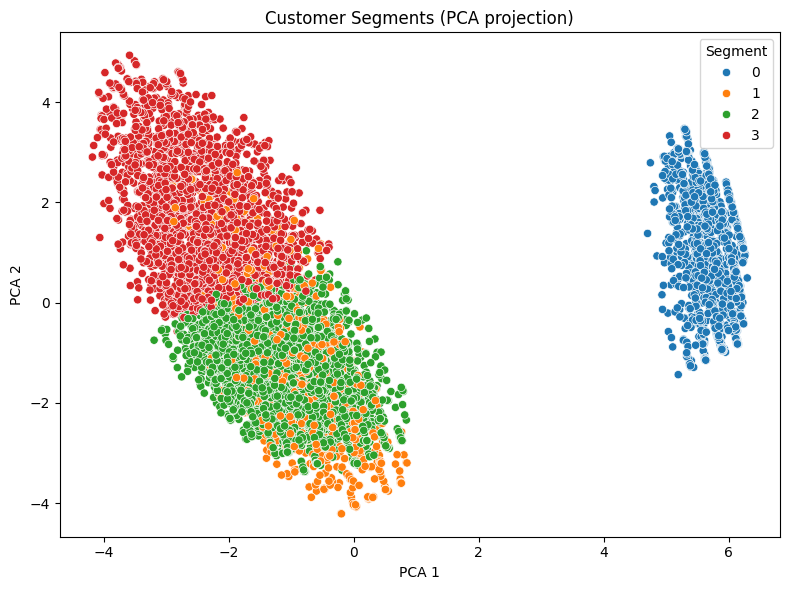

In [ ]:

# Prepare a 2D PCA projection of the scaled segmentation features
plt.figure(figsize=(8, 6))
pca = PCA(n_components=2, random_state=42)
seg_pca = pca.fit_transform(seg_scaled)

# Plot the PCA projection, coloring points by the assigned segment label
sns.scatterplot(
    x=seg_pca[:, 0],
    y=seg_pca[:, 1],
    hue=segment_labels,
    palette='tab10',
    legend='full'
)
plt.title('Customer Segments (PCA projection)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Segment')
plt.tight_layout()
plt.show()

   Segment  customers  churn_rate  avg_tenure  avg_monthly    avg_total
0        0       1520    7.434211   30.667763    21.076283   665.220329
1        1        680   25.000000   31.830882    41.992500  1500.433750
2        2       2733   46.688621   15.538968    73.965368  1171.147384
3        3       2099   14.768938   55.865650    91.911768  5156.737994


C:\Users\user\AppData\Local\Temp\ipykernel_1992\3177400077.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_characteristics, x='Segment', y='churn_rate', palette='Set2')
C:\Users\user\AppData\Local\Temp\ipykernel_1992\3177400077.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_characteristics, x='Segment', y='avg_tenure', palette='Set2')
C:\Users\user\AppData\Local\Temp\ipykernel_1992\3177400077.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_characteristics, x='Segment', y='avg_monthly', p

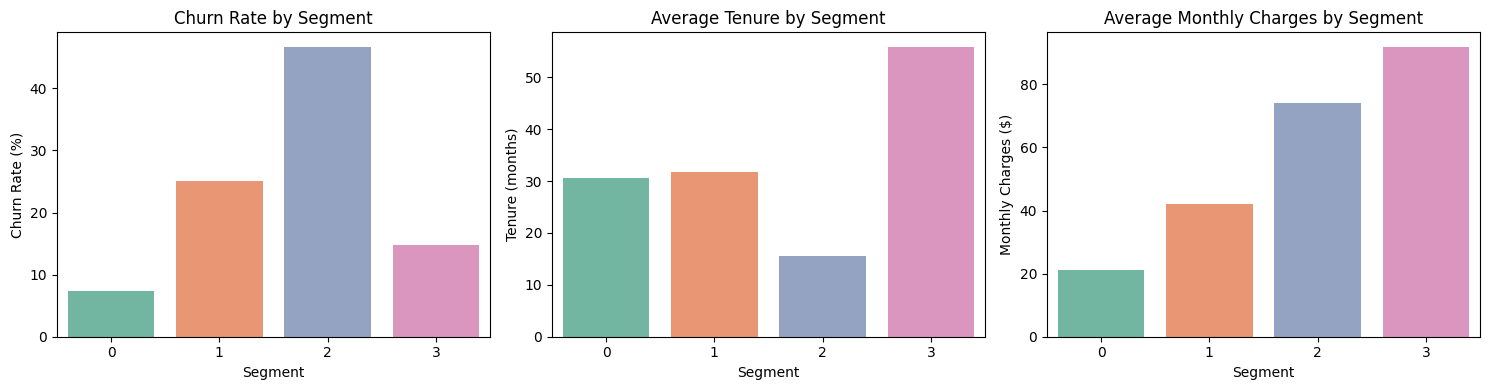

In [35]:
# Aggregate key segment characteristics for reporting
segment_characteristics = seg_df.groupby('Segment').agg(
    customers=('Churn', 'count'),
    churn_rate=('Churn', lambda s: (s == 'Yes').mean() * 100),
    avg_tenure=('tenure', 'mean'),
    avg_monthly=('MonthlyCharges', 'mean'),
    avg_total=('TotalCharges', 'mean')
).reset_index()

# Print the aggregated segment summary dataframe
print(segment_characteristics)

# Plot segment characteristics in a single row of bar charts
plt.figure(figsize=(15, 4))

# Plot churn rate for each segment
plt.subplot(1, 3, 1)
sns.barplot(data=segment_characteristics, x='Segment', y='churn_rate', palette='Set2')
plt.title('Churn Rate by Segment')
plt.ylabel('Churn Rate (%)')

# Plot average tenure for each segment
plt.subplot(1, 3, 2)
sns.barplot(data=segment_characteristics, x='Segment', y='avg_tenure', palette='Set2')
plt.title('Average Tenure by Segment')
plt.ylabel('Tenure (months)')

# Plot average monthly charges for each segment
plt.subplot(1, 3, 3)
sns.barplot(data=segment_characteristics, x='Segment', y='avg_monthly', palette='Set2')
plt.title('Average Monthly Charges by Segment')
plt.ylabel('Monthly Charges ($)')

plt.tight_layout()
# Display the segment characteristic bar charts
plt.show()

In [36]:
# print the total number of customers in the dataset
print(f"Total Customers: {total_customers}")

# print how many customers have churned
print(f"Churned Customers: {churned_customers}")

# print the churn rate as a percentage
print(f"Churn Rate: {churn_rate:.2f}%")

# print the average monthly revenue per user
print(f"Average Revenue Per User (ARPU): ${average_revenue_per_user:.2f}")

# print the basic customer lifetime value using mean TotalCharges
print(f"Customer Lifetime Value (mean TotalCharges): ${Customer_Lifetime_values:.2f}")

# print the summary of customer segments from the clustering
print("\nSegment summary:")
print(segment_summary)

Total Customers: 7032
Churned Customers: 1869
Churn Rate: 26.58%
Average Revenue Per User (ARPU): $64.80
Customer Lifetime Value (mean TotalCharges): $2283.30

Segment summary:
   Segment  customers  churn_rate  avg_tenure  avg_monthly    avg_total
0        0       1520    7.434211   30.667763    21.076283   665.220329
1        1        680   25.000000   31.830882    41.992500  1500.433750
2        2       2733   46.688621   15.538968    73.965368  1171.147384
3        3       2099   14.768938   55.865650    91.911768  5156.737994
